In [3]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


## MM Functions

In [4]:
class KineticDataException(Exception):
    pass

In [5]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [6]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 5
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        #curr_times = [item for sublist in perc_times[:i] for item in sublist]
        #curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
        #return float('nan'), float('nan'), float('nan')
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [41]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                ax.scatter(time_arr, data)
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x, x * slope + intercept)
           
    return np.concatenate(slopes)

In [8]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [9]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 1000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# Data Cleaning and Prep

In [10]:
df = pd.read_csv("../data/20220519_full_mm_gsadk_sdm-1.csv", header=0)

In [9]:
df.head()

,Cycle Nr.,Time [s],Temp. [°C],E1,E2,E3,E4,E5,E6,E7,...,J7,J8,J9,J10,J11,J12,J13,J14,J15,J16
0,1,0.000,28.7,8949,8905,4657,5286,3665,3320,2898,...,2669,2894,2160,2266,2207,2020,1848,1978,1871,1927
1,2,65.403,28.6,8812,8714,4534,4977,3458,3189,2793,...,2625,2625,2179,2225,2176,2003,1834,1976,1798,1937
2,3,130.315,28.5,10990,8623,4486,5012,3441,3172,2705,...,2610,2637,2148,2217,2160,2017,1858,1962,1801,1917
3,4,195.222,28.5,10716,8684,4564,4966,3502,3174,2688,...,2571,2677,2195,2257,2185,2015,1871,1976,1799,1928
4,5,260.134,28.5,10289,8625,4538,4931,3409,3195,2709,...,2585,2667,2157,2234,2198,2039,1874,1969,1806,1887


In [11]:
time_arr = np.array(df["Time [s]"])

In [12]:
time_arr.shape

(222,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

# Computing Background Rates

In [13]:
RFU_TO_NADPH_CONVERSION_FACTOR = 179

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

In [14]:
no_enz_df = df.iloc[:, 88:104]

In [15]:
no_enz_df

,J1,J2,J3,J4,J5,J6,J7,J8,J9,J10,J11,J12,J13,J14,J15,J16
0,7658,7275,5791,4485,3459,3384,2669,2894,2160,2266,2207,2020,1848,1978,1871,1927
1,7595,7405,5571,4537,3416,3381,2625,2625,2179,2225,2176,2003,1834,1976,1798,1937
2,7572,7266,5499,4473,3409,3351,2610,2637,2148,2217,2160,2017,1858,1962,1801,1917
3,7603,7231,5483,4484,3422,3348,2571,2677,2195,2257,2185,2015,1871,1976,1799,1928
4,7536,7192,5501,4472,3392,3352,2585,2667,2157,2234,2198,2039,1874,1969,1806,1887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,11128,10972,9077,8973,7710,8415,7035,6879,6854,6704,6626,6470,6943,6582,6529,6794
218,11400,11180,9257,9165,7832,8710,7212,6979,6826,6684,6721,6545,6973,6635,6564,6775
219,11442,11158,9227,9084,7908,8563,7063,6987,6793,6697,6759,6517,7027,6643,6557,6837
220,11232,11069,9167,8925,7779,8552,7133,6957,6866,6675,6692,6599,7076,6556,6609,6812


In [16]:
no_enz_arr = np.array(no_enz_df) / RFU_TO_NADPH_CONVERSION_FACTOR
no_enz_arr.shape

(222, 16)

We need to transpose our array as our desired time count dimension is currently the first dimension.

In [17]:
no_enz_arr = no_enz_arr.transpose()
no_enz_arr.shape

(16, 222)

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

In [18]:
no_enz_rep_1_arr = no_enz_arr[0::2]
no_enz_rep_2_arr = no_enz_arr[1::2]

In [19]:
sub_concs = [1000, 500, 250, 125, 62.5, 31.25, 15.625, 7.8125]

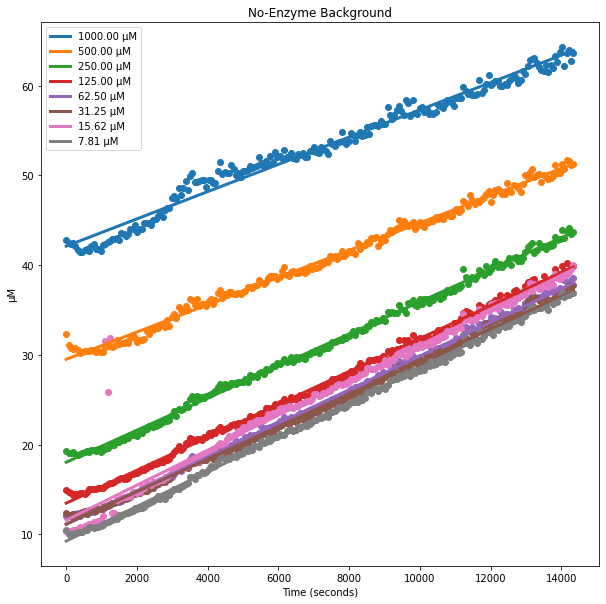

In [20]:
no_enz_rep_1_slopes = get_initial_slopes(time_arr, no_enz_rep_1_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background")

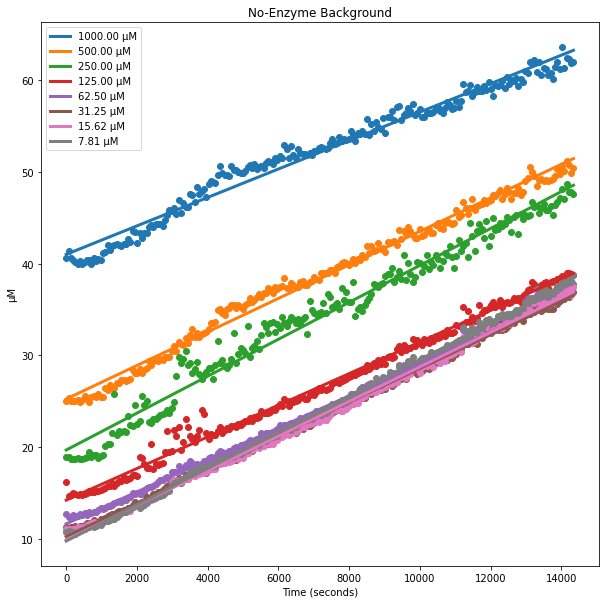

In [21]:
no_enz_rep_2_slopes = get_initial_slopes(time_arr, no_enz_rep_2_arr, plot=True, substrate_concs=sub_concs,
                   title="No-Enzyme Background")

# gsADK I111L Data

In [22]:
gs_i111l_df = df.iloc[:, 20:36]
gs_i111l_arr = np.array(gs_i111l_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [23]:
gs_i111l_rep_1_arr = gs_i111l_arr[0::2]
gs_i111l_rep_2_arr = gs_i111l_arr[1::2]

In [24]:
gs_i111l_conc = .618 * 2e-4

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

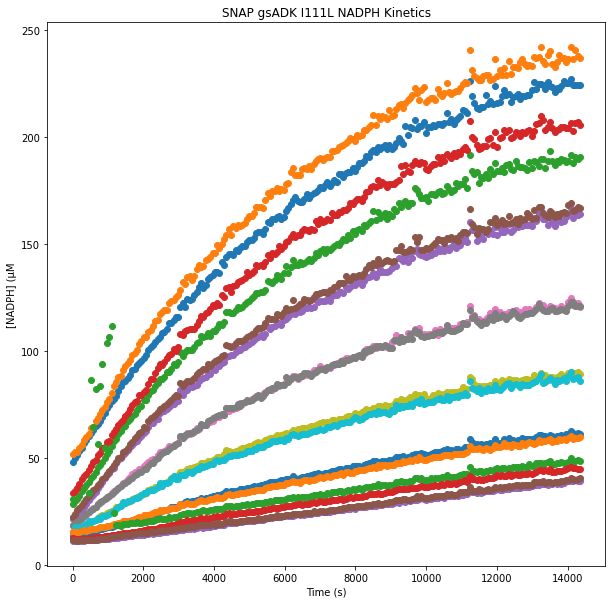

In [32]:
fig = plt.figure(figsize=(10,10))

for data in gs_i111l_arr:
    plt.scatter(time_arr, data)
plt.title("SNAP gsADK I111L NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

/usr/local/anaconda3/envs/processing/lib/python3.7/site-packages/ipykernel_launcher.py:28: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.


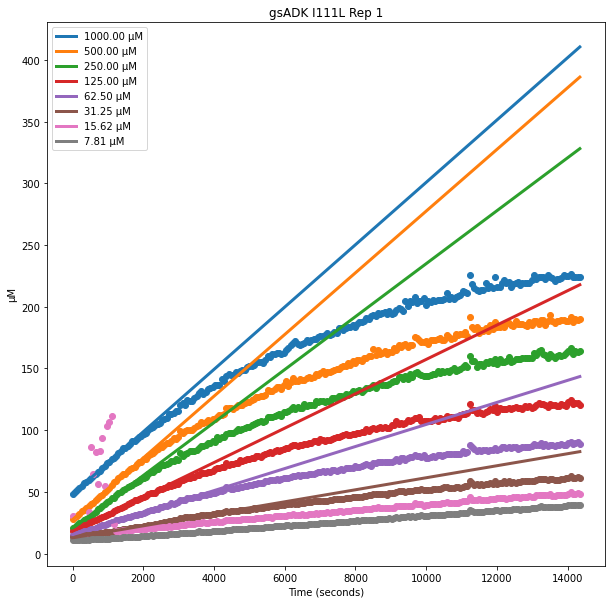

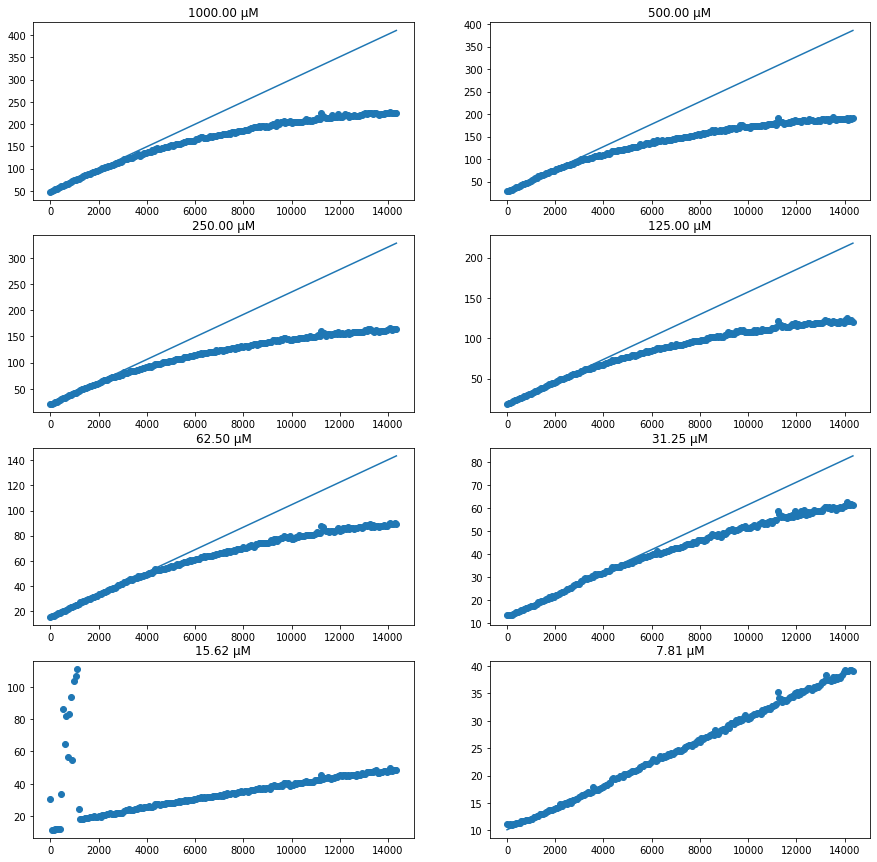

In [42]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="gsADK I111L Rep 1", triage=True)

In [34]:
gsADK_i111l_r1_slopes

array([0.02526065, 0.02499829, 0.02145291, 0.01392661, 0.0089345 ,
       0.00486923,        nan, 0.00205182])

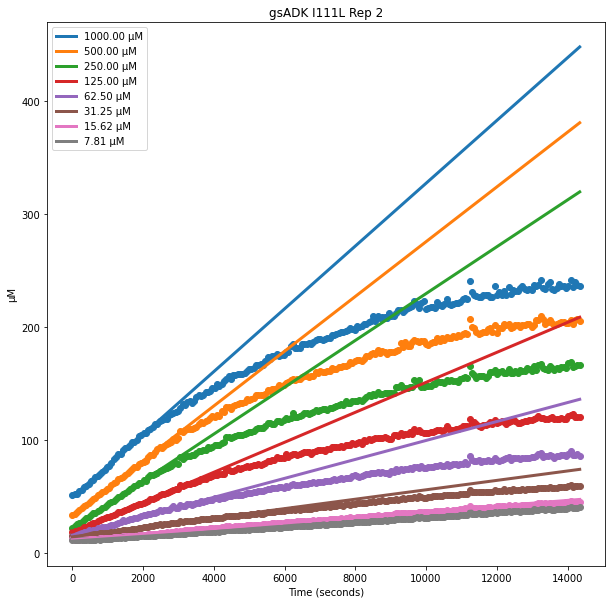

In [36]:
gsADK_i111l_r2_slopes = get_initial_slopes(time_arr, gs_i111l_rep_2_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="gsADK I111L Rep 2")

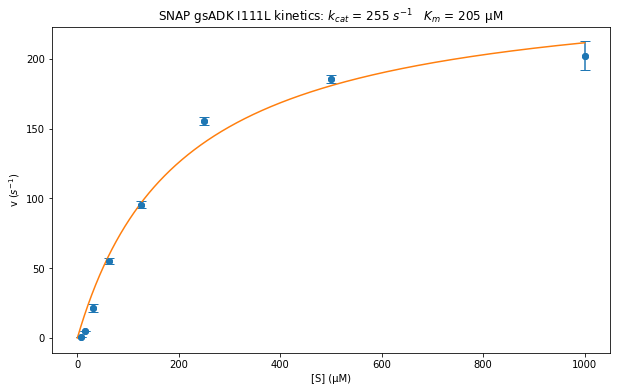

In [40]:
fit_and_plot_micheaelis_menten(np.array(gsADK_i111l_r1_slopes), np.array(gsADK_i111l_r2_slopes), sub_concs, 
                               gs_i111l_conc, "SNAP gsADK I111L", np.mean([no_enz_rep_1_slopes, no_enz_rep_2_slopes], axis=0)[..., np.newaxis])

Cut off initial rxn data when flat/artifcact